In [1]:
import os
import sys
import pandas as pd
import numpy as np
import anndata as ad
import datetime
import traceback
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.sparse import csr_matrix
import re

# Input file path (make sure using most recent aligned anndatas)
GE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/062025/ge_adata_matched_2025-06-23.h5ad"
SPLICE_INPUT = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/062025/splice_adata_matched_2025-06-23.h5ad"

# Read the input file
ge_adata = ad.read_h5ad(GE_INPUT)
splice_adata = ad.read_h5ad(SPLICE_INPUT)

# Check the number of cells and genes
print(f"Number of cells: {ge_adata.n_obs}")
print(f"Number of genes: {ge_adata.n_vars}")

Number of cells: 88518
Number of genes: 30340


### Types of QC to do before saving final splicing and GE anndatas....
- Gene expression based QC
- Splicing based QC, ensure reasonable number of junctions detected in cells... 
- Calculate nuclear vs cytoplasmic score...

In [2]:
# Clean up GE gene info...
gene_info_df = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/processed_data/gene_info_df_2025-06-22.csv")
gene_info_df["gene_symbol"] = gene_info_df["gene_name"]
ge_adata.var["gene_symbol"] = ge_adata.var.index.values
ge_adata.var_names = ge_adata.var["gene_symbol"]
# reset the index
ge_adata.var = ge_adata.var.reset_index(drop=True)
# Merge gene info into var
ge_adata.var = ge_adata.var.merge(gene_info_df, on="gene_symbol", how="left")

print("Clean up cell ids...")
# Confirm that the cell ids are the same
splice_adata.obs_names = splice_adata.obs["cell_id_clean"]
ge_adata.obs_names = ge_adata.obs["cell_id_clean"]
# Assert that obs_names are the same
assert np.all(ge_adata.obs_names == splice_adata.obs_names)
# Assert that the cells are in the same order
assert np.all(ge_adata.obs["cell_id_clean"].values == splice_adata.obs["cell_id_clean"].values)

Clean up cell ids...


### Quality-control pipeline  (overview)

1. **Flag rRNA genes**  
   * Parse the comma-separated `transcript_biotypes` column.  
   * Mark any entry that contains `rRNA` or `rRNA_pseudogene` → `is_rRNA = True`.

2. **Per-cell QC metrics** (`scanpy.pp.calculate_qc_metrics`)  
   * Input layer: raw counts  
   * Extra QC var: `is_rRNA` → adds `total_counts_is_rRNA` and `pct_counts_is_rRNA`.

3. **Batch-aware outlier detection**  
   For each `batch` separately:  
   * Compute the **median** and **MAD** (median-absolute-deviation) of  
     * library size (`total_counts`)  
     * number of detected genes (`n_genes_by_counts`) using raw counts.
   * Convert both features to robust z-scores  
     \[
       z = \frac{x-\text{median}}{\text{MAD}\times1.4826}
     \]
     (1.4826 rescales MAD to σ for a normal distribution).

4. **Cell filtering rules**  
   * │z│ > 3 for *either* library size *or* genes detected → drop  
   * `pct_counts_is_rRNA` ≥ 10 % → drop  
   * missing `broad_cell_type` annotation → drop  

5. **Result**  
   After filtering **80,904** cells remain (from initial set of 88,518).

6. **Feature selection for integration**  
   From the `predicted_log_norm_tms` layer, keep the **10 000** most highly variable genes for all downstream analyses.


In [3]:
# ---------- 0   Tag rRNA genes once ---------------------------------
# non-capturing groups (?: … ) silence the pandas warning
rrna_regex = r'(?:^|,\s*)rRNA(?:_pseudogene)?(?:$|,\s*)'
ge_adata.var['is_rRNA'] = ge_adata.var['transcript_biotypes'].str.contains(
    rrna_regex, regex=True, na=False
)

# ---------- 1   All QC metrics in a single scanpy call --------------
sc.pp.calculate_qc_metrics(
    ge_adata,
    qc_vars=['is_rRNA'],               # adds total_counts_is_rRNA & pct_counts_is_rRNA
    layer='raw_counts',
    percent_top=None,
    inplace=True
)

# ---------- 2   Batch-wise robust stats (median ± MAD) --------------
stats = (
    ge_adata.obs
      .groupby('batch')
      .agg(
          n_genes_median = ('n_genes_by_counts', 'median'),
          n_genes_mad    = ('n_genes_by_counts',
                            lambda x: np.median(np.abs(x - np.median(x)))),
          counts_median  = ('total_counts',       'median'),
          counts_mad     = ('total_counts',
                            lambda x: np.median(np.abs(x - np.median(x))))
      )
)
qc = ge_adata.obs.join(stats, on='batch')

sf = 1.4826     # converts MAD -> SD for a normal distribution
z_genes  = (qc['n_genes_by_counts'] - qc['n_genes_median']) / (sf * qc['n_genes_mad'])
z_counts = (qc['total_counts']       - qc['counts_median'])  / (sf * qc['counts_mad'])

gene_filter   = (-3 <= z_genes)  & (z_genes  <= 3)        # keep within ±3 "robust SD"
count_filter  = (-3 <= z_counts) & (z_counts <= 3)
rrna_filter   =  qc['pct_counts_is_rRNA'] < 10
label_filter  =  qc['broad_cell_type'].notna()

keep = gene_filter & count_filter & rrna_filter & label_filter
ge_adata = ge_adata[keep].copy()
print(f"Retained {ge_adata.n_obs} cells")

/scratch/ipykernel_2599270/2464379257.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('batch')


Retained 80904 cells


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Calculate nuclear score using nuclear and cytoplasmic marker genes + ribosomal RNA expression

In [4]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

NUCLEAR_GENES = ['MALAT1','NEAT1','XIST','MEG3','KCNQ1OT1',
                 'PVT1','GAS5','SNHG1','SNHG6']
CYTO_GENES    = ['RPL3','RPL4','RPL5','RPL6','RPL7','RPL8',
                 'RPS2','RPS3','RPS4X','RPS6','RPS8','RPS9',
                 'EEF1A1','EEF2','ACTB','GAPDH']

def add_nuclear_score(
        adata,
        layer=('log_norm',),            # str or tuple/list
        verbose=True,
        weights=dict(ratio=.5, rrna=.5) # must sum to 1.0
):
    if isinstance(layer, str):
        layer = (layer,)

    gnames = adata.var.get('gene_name', adata.var_names).str.upper()
    nuc_idx  = np.flatnonzero(gnames.isin([g.upper() for g in NUCLEAR_GENES]))
    cyto_idx = np.flatnonzero(gnames.isin([g.upper() for g in CYTO_GENES]))
    rrna_idx = np.flatnonzero(adata.var.get('is_rRNA', False))

    if verbose:
        print(f'nuclear genes: {len(nuc_idx)}/{len(NUCLEAR_GENES)}, '
              f'cyto: {len(cyto_idx)}/{len(CYTO_GENES)}, '
              f'rRNA: {rrna_idx.size}')

    mean1d = lambda M, idx: np.asarray(M[:, idx].mean(axis=1)).ravel() if idx.size else np.zeros(adata.n_obs)
    sum1d  = lambda M, idx: np.asarray(M[:, idx].sum(axis=1)).ravel()  if idx.size else np.zeros(adata.n_obs)
    z      = lambda v: zscore(v, nan_policy='omit')

    for lyr in layer:
        X = adata.layers.get(lyr, adata.X)

        # component 1 – nuclear / cytoplasmic ratio
        nuc_expr  = mean1d(X, nuc_idx)
        cyto_expr = mean1d(X, cyto_idx)
        ratio_z   = z(np.log2((nuc_expr + 1)/(cyto_expr + 1)))

        # component 2 – rRNA depletion
        rrna_expr  = sum1d(X, rrna_idx)
        total_expr = np.asarray(X.sum(axis=1)).ravel()
        rrna_frac  = rrna_expr / (total_expr + 1e-9)
        rrna_z     = z(-np.log10(rrna_frac + 1e-9))

        composite = (weights['ratio'] * ratio_z +
                     weights['rrna'] * rrna_z)

        composite = (composite - composite.min()) / (composite.max() - composite.min() + 1e-9)

        suf = '' if len(layer) == 1 else f'_{lyr}'
        adata.obs[f'nuclear_score{suf}'] = composite
        adata.obs[f'nuclear_ratio{suf}'] = ratio_z
        adata.obs[f'nuclear_rrna{suf}']  = rrna_z
        adata.obs[f'nuclear_class{suf}'] = pd.cut(
            composite, bins=[0, .25, .75, 1],
            labels=['cellular','mixed','nuclear'],  include_lowest=True
        )
    return adata


nuclear genes: 9/9, cyto: 16/16, rRNA: 451


/scratch/ipykernel_2599270/3218778909.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = ge_adata.obs.groupby('batch')[score_col].median()


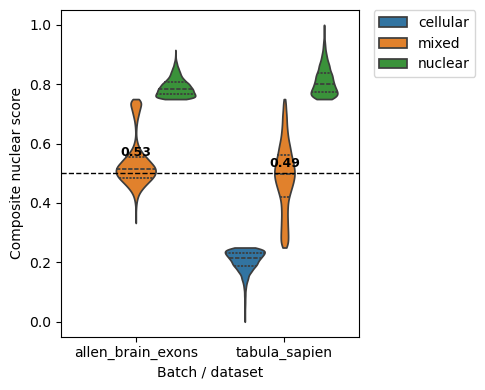

In [5]:
ge_adata = add_nuclear_score(
    ge_adata,
    layer=('log_norm', 'length_norm'),
    verbose=True
)

# Summarize with plot 
cls_col   = 'nuclear_class_log_norm'
score_col = 'nuclear_score_log_norm'   # or nuclear_score_length_norm

palette   = {'cellular':'#d62728', 'mixed':'#ff7f0e', 'nuclear':'#2ca02c'}

fig, ax = plt.subplots(figsize=(5,4))

# 1️violin per batch
sns.violinplot(
    data = ge_adata.obs,
    hue = cls_col,
    x    = 'batch',
    y    = score_col,
    ax   = ax,
    inner='quartile',      # draw the Q1–median–Q3 bars
    cut  = 0
)

# Move legend outside of plot
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# 2️dashed line at y = 0.5
ax.axhline(0.5, ls='--', lw=1, color='black')

# 3️annotate median for each batch
medians = ge_adata.obs.groupby('batch')[score_col].median()
for tick, batch in enumerate(medians.index):
    y = medians[batch]
    ax.text(tick, y + 0.02,          # slight upward offset
            f"{y:.2f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Composite nuclear score')
ax.set_xlabel('Batch / dataset')
plt.tight_layout()
plt.show()


In [6]:
print(ge_adata.obs[["dataset", "nuclear_class_log_norm"]].value_counts())

dataset         nuclear_class_log_norm
allen_brain     mixed                     39605
tabula_sapiens  mixed                     30070
allen_brain     nuclear                    6941
tabula_sapiens  cellular                   3009
                nuclear                    1279
Name: count, dtype: int64


In [7]:
# read the aging-gene table you pasted
df = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/062025/global_aging_genes.tsv", sep="\t")
# positive genes = those whose coefficient > 0  (up-regulated with age)
age_pos = df.loc[df.gag_score_coef > 0, "global_aging_genes"].str.upper().tolist()
# negative genes = coefficient < 0 (down-regulated with age)
age_neg = df.loc[df.gag_score_coef < 0, "global_aging_genes"].str.upper().tolist()
ge_adata.X = ge_adata.layers["log_norm"]

# be sure var_names are also upper-case to match
ge_adata.var_names = ge_adata.var["gene_name"]

# --- Up-regulated gene score ---
sc.tl.score_genes(
    ge_adata,
    gene_list=age_pos,
    score_name="AgingScore_pos"
)

# --- Down-regulated gene score ---
sc.tl.score_genes(
    ge_adata,
    gene_list=age_neg,
    score_name="AgingScore_neg"
)

# Final composite (higher = “older”)
ge_adata.obs["AgingScore_unweighted"] = (
    ge_adata.obs["AgingScore_pos"] - ge_adata.obs["AgingScore_neg"]
)

       'H2-AB1', 'H2-D1', 'H2-K1', 'LYZ2', 'RNASET2B', 'SEPW1'],
      dtype='object')
       'ERBB2IP', 'HIST1H4D', 'MATR3', 'ROD1', 'SEPP1', 'SEPT2', 'SHFM1',
       'SKP1A', 'SPNB2', 'SYPL', 'USMG5', 'ZFP106', 'ZFP207'],
      dtype='object')


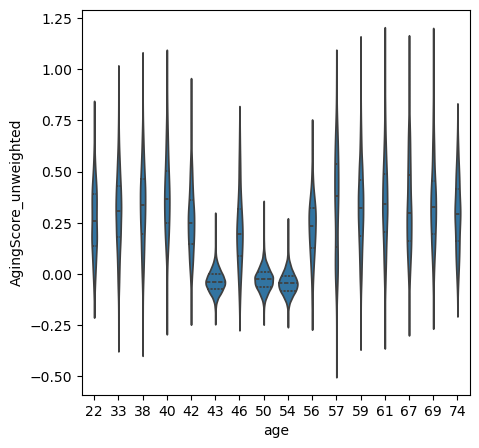

In [8]:
# Make violin plot of aging score
plt.figure(figsize=(5, 5))
sns.violinplot(data=ge_adata.obs, x="age", y="AgingScore_unweighted", inner="quartile")
plt.show()

#### Do marker gene analysis as sanity check that regression based adjustment worked...  

In [9]:
# ---------- 4   Select 10 000 HVGs (predicted_log_norm_tms layer) ----
sc.pp.highly_variable_genes(
    ge_adata,
    layer='log_norm',
    n_top_genes=15_000,
    inplace=True
)

ge_adata = ge_adata[:, ge_adata.var['highly_variable']].copy()
print(f"Shape after HVG subset: {ge_adata.shape}")

Shape after HVG subset: (80904, 15000)


In [10]:
# ensure splice_adata has only the same cells as remain in ge_adata 
splice_adata = splice_adata[ge_adata.obs_names].copy()
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [11]:
splice_adata.var["clean_gene_id"] = splice_adata.var["gene_id"].str.split(".").str[0]
ge_adata.var["clean_gene_id"] = ge_adata.var["gene_id"].str.split(".").str[0]

In [12]:
gene_info = ge_adata.var[["clean_gene_id", "gene_name", "mean_transcript_length", "mean_intron_length", "num_transcripts", "transcript_biotypes", "n_cells_by_counts", "mean_counts"]]
# remove index column
gene_info = gene_info.reset_index(drop=True)
splice_adata.var.drop(columns=["gene_name"], inplace=True)

# restrict splice_adata to the same genes in ge_adata
splice_adata = splice_adata[:, splice_adata.var["clean_gene_id"].isin(ge_adata.var["clean_gene_id"])].copy()
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

# merge with splice_adata.var
splice_adata.var = splice_adata.var.merge(gene_info, on="clean_gene_id")

# Now subset ge_adata to the same genes in splice_adata
ge_adata = ge_adata[:, ge_adata.var["clean_gene_id"].isin(splice_adata.var["clean_gene_id"])].copy()
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [13]:
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

# Assert that the cells are in the same order
assert np.all(ge_adata.obs["cell_id_clean"].values == splice_adata.obs["cell_id_clean"].values)

In [14]:
print(f"Final number of unique cells in splice_adata: {splice_adata.n_obs}")
print(f"Final number of unique junctions in splice_adata: {splice_adata.n_vars}")
print(f"Final number of unique ATSEs in splice_adata: {splice_adata.var['event_id'].nunique()}")
print(f"Final number of unique genes in splice_adata: {splice_adata.var['gene_name'].nunique()}")

print(f"Final number of unique cells in ge_adata: {ge_adata.n_obs}")
print(f"Final number of unique genes in ge_adata: {ge_adata.n_vars}")

Final number of unique cells in splice_adata: 80904
Final number of unique junctions in splice_adata: 113378
Final number of unique ATSEs in splice_adata: 27083
Final number of unique genes in splice_adata: 7182
Final number of unique cells in ge_adata: 80904
Final number of unique genes in ge_adata: 7182


In [15]:
print("=== ADDING COMPUTED SCORES TO SPLICE DATA ===")
# add the new .obs columns to the splice_adata
splice_adata.obs["broad_cell_type"] = ge_adata.obs["broad_cell_type"]
splice_adata.obs["AgingScore_unweighted"] = ge_adata.obs["AgingScore_unweighted"]
splice_adata.obs["AgingScore_pos"] = ge_adata.obs["AgingScore_pos"]
splice_adata.obs["AgingScore_neg"] = ge_adata.obs["AgingScore_neg"]
print("✓ Added aging scores and cell type annotations to splice data")

print("=== ADDING COMPUTED NUCLEAR RATIO SCORES TO SPLICE DATA ===")
splice_adata.obs["nuclear_ratio_log_norm"] = ge_adata.obs["nuclear_ratio_log_norm"]

=== ADDING COMPUTED SCORES TO SPLICE DATA ===
✓ Added aging scores and cell type annotations to splice data
=== ADDING COMPUTED NUCLEAR RATIO SCORES TO SPLICE DATA ===


In [16]:
assert np.all(ge_adata.obs_names == splice_adata.obs_names)

In [17]:
import os
from datetime import datetime

# Set new model date and shared output directory
new_model_date = "062025"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
GE_OUTPUT_DIR = f"/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/{new_model_date}"
os.makedirs(GE_OUTPUT_DIR, exist_ok=True)

# ---- Gene Expression ----
ge_new_filename = f"aligned_gene_expression_data_{timestamp}.h5ad"
GE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, ge_new_filename)

# Save filtered gene expression data
ge_adata.write(GE_OUTPUT_PATH, compression="lzf")
print(f"Filtered gene expression AnnData written to:\n{GE_OUTPUT_PATH}")

# ---- Splicing Data ----
splice_new_filename = f"aligned_splicing_data_{timestamp}.h5ad"
SPLICE_OUTPUT_PATH = os.path.join(GE_OUTPUT_DIR, splice_new_filename)

# Subset and save matched splicing data
splice_adata.write(SPLICE_OUTPUT_PATH, compression="lzf")
print(f"Filtered splicing AnnData written to:\n{SPLICE_OUTPUT_PATH}")

Filtered gene expression AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/062025/aligned_gene_expression_data_20250627_163745.h5ad
Filtered splicing AnnData written to:
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/MODEL_INPUT/062025/aligned_splicing_data_20250627_163745.h5ad


In [18]:
# Save also text file with just final list of cell ids 
with open(os.path.join(GE_OUTPUT_DIR, "filtered_cell_ids.txt"), "w") as f:
    for cell_id in ge_adata.obs_names:
        f.write(f"{cell_id}\n")

In [20]:
splice_adata.obs

,cell_id,donor,sex,age,dataset,tissue,cell_type_grouped,cell_type,broad_cell_type,cell_id_index,cell_id_clean,AgingScore_unweighted,AgingScore_pos,AgingScore_neg,nuclear_ratio_log_norm
cell_id_clean,,,,,,,,,,,,,,,
F1S4_160106_001_B01,F1S4_160106_001_B01,H200.1030,M,54,allen_brain,MTG,SST,Inh L4-6 SST MTHFD2P6,Inhibitory_Neuron,68184,F1S4_160106_001_B01,-0.003566,0.223656,0.227222,0.470419
F1S4_160106_001_D01,F1S4_160106_001_D01,H200.1030,M,54,allen_brain,MTG,IT,Exc L3-4 RORB FOLH1B,Excitatory_Neuron,9746,F1S4_160106_001_D01,-0.056994,-0.045722,0.011271,1.486135
F1S4_160106_001_E01,F1S4_160106_001_E01,H200.1030,M,54,allen_brain,MTG,L6 CT,Exc L6 FEZF2 FAM95C,Excitatory_Neuron,44300,F1S4_160106_001_E01,-0.184714,-0.010065,0.174649,1.023079
F1S4_160106_001_G01,F1S4_160106_001_G01,H200.1030,M,54,allen_brain,MTG,L6b,Exc L6 FEZF2 TBC1D26,Excitatory_Neuron,31896,F1S4_160106_001_G01,-0.091709,0.068152,0.159862,0.597381
F1S4_160106_001_H01,F1S4_160106_001_H01,H200.1030,M,54,allen_brain,MTG,IT,Exc L4-5 RORB LINC01474,Excitatory_Neuron,21264,F1S4_160106_001_H01,-0.070304,0.099954,0.170258,0.380188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP8_donor_B134141_M3_B134697_M3_Prostate_Immune,TSP8_TSP8_smartseq2_B134141_B134697_Prostate_N...,TSP8,male,56,tabula_sapiens,Prostate,smooth muscle cell,smooth muscle cell,Smooth_Muscle,82335,TSP8_donor_B134141_M3_B134697_M3_Prostate_Immune,0.089150,0.087862,-0.001288,0.942790
TSP8_donor_B134141_M8_B134697_M8_Prostate_Immune,TSP8_TSP8_smartseq2_B134141_B134697_Prostate_N...,TSP8,male,56,tabula_sapiens,Prostate,luminal epithelial cell,luminal cell of prostate epithelium,Mammary_Epithelial,67299,TSP8_donor_B134141_M8_B134697_M8_Prostate_Immune,-0.010183,-0.041357,-0.031174,-0.079019
TSP8_donor_B134141_N20_B134697_N20_Prostate_Immune,TSP8_TSP8_smartseq2_B134141_B134697_Prostate_N...,TSP8,male,56,tabula_sapiens,Prostate,luminal epithelial cell,luminal cell of prostate epithelium,Mammary_Epithelial,76146,TSP8_donor_B134141_N20_B134697_N20_Prostate_Im...,-0.088609,-0.041806,0.046803,0.260900
